In [36]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

In [37]:
# Loading dataset
file_path = "/Users/Mbongeleni/Library/CloudStorage/OneDrive-StellenboschUniversity/Documents/CSIR/SANAE/SANAE_Combined_Underway_clean.xlsx"
df = pd.read_excel(file_path)

/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/4045308971.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eqn = f"{biome}\nTA = {coef[0]:.2f} + {coef[1]:.2f}·CT\nR² = {model.rsquared:.3f}"
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/4045308971.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eqn = f"{biome}\nTA = {coef[0]:.2f} + {coef[1]:.2f}·CT\nR² = {model.rsquared:.3f}"
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/4045308971.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will al

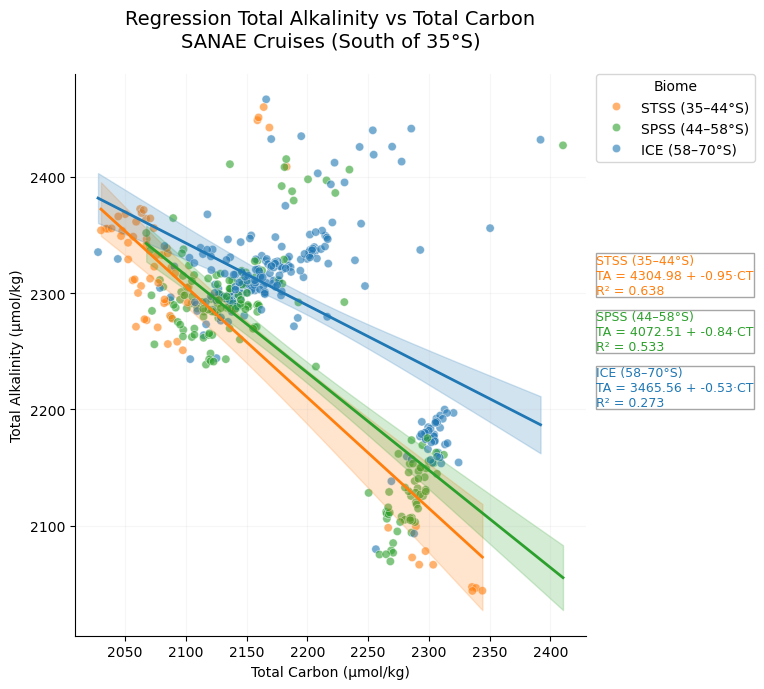


Biome-wise Mean, Std, and Sample Size for CT and TA:
         Biome  Mean CT  Std CT  Mean TA  Std TA   n
STSS (35–44°S)  2115.30   91.67  2290.98  109.27  62
SPSS (44–58°S)  2179.18   76.87  2249.00   88.12 185
 ICE (58–70°S)  2195.83   70.05  2291.68   71.68 215


In [38]:
# --- Biome assignment function ---
def assign_biome(lat):
    if -44 <= lat < -35:
        return "STSS (35–44°S)"
    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"
    elif -70 <= lat < -58:
        return "ICE (58–70°S)"
    else:
        return "Outside Defined Biome"

# --- Filter for summer only ---
df_summer = df[df['Season'].str.lower() == 'summer'].copy()

# --- Assign biomes ---
df_summer['Biome'] = df_summer['Lat'].apply(assign_biome)

# --- Exclude outside biomes ---
biome_order = ["STSS (35–44°S)", "SPSS (44–58°S)", "ICE (58–70°S)"]
df_summer = df_summer[df_summer['Biome'].isin(biome_order)]

# --- Create Figure ---
fig, ax = plt.subplots(figsize=(10,7))

# --- Scatterplot with biome colors ---
sns.scatterplot(
    data=df_summer,
    x='Total Carbon',
    y='Total Alkalinity',
    hue='Biome',
    hue_order=biome_order,
    palette={
        'STSS (35–44°S)': '#ff7f0e',
        'SPSS (44–58°S)': '#2ca02c',
        'ICE (58–70°S)': '#1f77b4'
    },
    alpha=0.6,
    ax=ax
)

# --- Regression lines, equations, confidence intervals ---
summary_stats = []

for biome, color in zip(biome_order, ['#ff7f0e', '#2ca02c', '#1f77b4']):
    subset = df_summer[df_summer['Biome'] == biome].dropna(subset=['Total Carbon','Total Alkalinity'])

    if len(subset) > 2:
        X = sm.add_constant(subset['Total Carbon'])
        y = subset['Total Alkalinity']
        model = sm.OLS(y, X).fit()
        coef = model.params

        # Regression line + CI
        x_vals = np.linspace(subset['Total Carbon'].min(), subset['Total Carbon'].max(), 100)
        X_pred = sm.add_constant(x_vals)
        y_pred = model.predict(X_pred)
        ci = model.get_prediction(X_pred).conf_int()

        ax.plot(x_vals, y_pred, color=color, lw=2)
        ax.fill_between(x_vals, ci[:,0], ci[:,1], color=color, alpha=0.2)

        # Equation annotation
        eqn = f"{biome}\nTA = {coef[0]:.2f} + {coef[1]:.2f}·CT\nR² = {model.rsquared:.3f}"
        ax.text(
            1.02,
            0.68 - 0.1*biome_order.index(biome),
            eqn,
            transform=ax.transAxes,
            fontsize=9,
            color=color,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', pad=0.2)
        )

        # Collect stats with sample size
        summary_stats.append([
            biome,
            subset['Total Carbon'].mean(),
            subset['Total Carbon'].std(),
            subset['Total Alkalinity'].mean(),
            subset['Total Alkalinity'].std(),
            len(subset)
        ])

# --- Formatting ---
ax.set_title("Regression Total Alkalinity vs Total Carbon\nSANAE Cruises (South of 35°S)", fontsize=14, pad=20)
ax.set_xlabel("Total Carbon (µmol/kg)")
ax.set_ylabel("Total Alkalinity (µmol/kg)")
ax.legend(title="Biome", loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
ax.grid(alpha=0.1)
sns.despine()
plt.tight_layout(rect=[0, 0, 0.78, 1])

# --- Save plots ---
plt.savefig("TA_vs_CT_Biomewise_Regression.png", dpi=600, bbox_inches='tight')
plt.savefig("TA_vs_CT_Biomewise_Regression.pdf", bbox_inches='tight')
plt.show()

# --- Summary statistics table ---
summary_df = pd.DataFrame(
    summary_stats,
    columns=["Biome", "Mean CT", "Std CT", "Mean TA", "Std TA", "n"]
)

print("\nBiome-wise Mean, Std, and Sample Size for CT and TA:")
print(summary_df.to_string(index=False, float_format="%.2f"))

# --- Export to CSV ---
summary_df.to_csv("TA_CT_Biomewise_Summary.csv", index=False, float_format="%.2f")


/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1752182387.py:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eqn = f"TA = {coef[0]:.2f} + {coef[1]:.2f}·CT"
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1752182387.py:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eqn = f"TA = {coef[0]:.2f} + {coef[1]:.2f}·CT"
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1752182387.py:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To acces

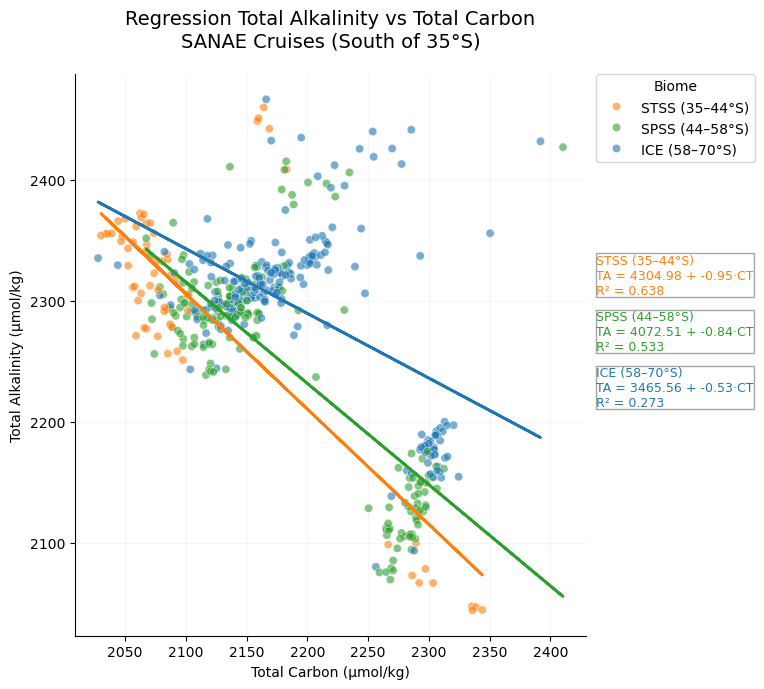


Biome-wise Mean and Std for CT and TA:
         Biome  Mean CT  Std CT  Mean TA  Std TA
STSS (35–44°S)  2115.30   91.67  2290.98  109.27
SPSS (44–58°S)  2179.18   76.87  2249.00   88.12
 ICE (58–70°S)  2195.83   70.05  2291.68   71.68


In [34]:
# Defining biome assignment function 
def assign_biome(lat):
    if -44 <= lat < -35:
        return "STSS (35–44°S)"
    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"
    elif -70 <= lat < -58:
        return "ICE (58–70°S)"
    else:
        return "Outside Defined Biome"

# Filter for summer only
df_summer = df[df['Season'].str.lower() == 'summer'].copy()

# Assign biomes
df_summer['Biome'] = df_summer['Lat'].apply(assign_biome)

# Exclude outside biomes
biome_order = ["STSS (35–44°S)", "SPSS (44–58°S)", "ICE (58–70°S)"]
df_summer = df_summer[df_summer['Biome'].isin(biome_order)]

# --- Create Figure ---
fig, ax = plt.subplots(figsize=(10,7))

# Scatterplot with biome colors
sns.scatterplot(
    data=df_summer,
    x='Total Carbon',
    y='Total Alkalinity',
    hue='Biome',
    hue_order=biome_order,
    palette={
        'STSS (35–44°S)': '#ff7f0e',
        'SPSS (44–58°S)': '#2ca02c',
        'ICE (58–70°S)': '#1f77b4'
    },
    alpha=0.6,
    ax=ax
)

# --- Add regression lines and equations ---
summary_stats = []

equation_text = ""

for biome, color in zip(
    biome_order,
    ['#ff7f0e', '#2ca02c', '#1f77b4']
):
    
    subset = df_summer[df_summer['Biome'] == biome]
    subset = subset.dropna(subset=['Total Carbon', 'Total Alkalinity'])

    if len(subset) > 2:
        
        X = sm.add_constant(subset['Total Carbon'])
        y = subset['Total Alkalinity']

        model = sm.OLS(y, X).fit()
        coef = model.params

        eqn = f"TA = {coef[0]:.2f} + {coef[1]:.2f}·CT"
        r2 = f"R² = {model.rsquared:.3f}"

        # Regression line
        x_vals = subset['Total Carbon']
        y_pred = model.predict(sm.add_constant(x_vals))

        ax.plot(
            x_vals,
            y_pred,
            color=color,
            lw=2
        )

        # Store equation text
        equation_text += f"{biome}\n{eqn}\n{r2}\n\n"

        # Collect mean and std
        mean_CT = subset['Total Carbon'].mean()
        std_CT = subset['Total Carbon'].std()

        mean_TA = subset['Total Alkalinity'].mean()
        std_TA = subset['Total Alkalinity'].std()

        summary_stats.append([
            biome,
            mean_CT,
            std_CT,
            mean_TA,
            std_TA
        ])

# --- Formatting ---
ax.set_title(
    "Regression Total Alkalinity vs Total Carbon\nSANAE Cruises (South of 35°S)",
    fontsize=14,
    pad=20
)

ax.set_xlabel("Total Carbon (µmol/kg)")
ax.set_ylabel("Total Alkalinity (µmol/kg)")

# --- Legend positioned top right ---
legend = ax.legend(
    title="Biome",
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0
)

# --- Equations below legend ---
y_positions = [0.68, 0.58, 0.48]

for y_pos, biome, color in zip(
    y_positions,
    biome_order,
    ['#ff7f0e', '#2ca02c', '#1f77b4']
):

    subset = df_summer[df_summer['Biome'] == biome]
    subset = subset.dropna(subset=['Total Carbon', 'Total Alkalinity'])

    if len(subset) > 2:

        X = sm.add_constant(subset['Total Carbon'])
        y = subset['Total Alkalinity']

        model = sm.OLS(y, X).fit()
        coef = model.params

        eqn = (
            f"{biome}\n"
            f"TA = {coef[0]:.2f} + {coef[1]:.2f}·CT\n"
            f"R² = {model.rsquared:.3f}"
        )

        ax.text(
            1.02,
            y_pos,
            eqn,
            transform=ax.transAxes,
            fontsize=9,
            color=color,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', pad=0.2)
        )

ax.grid(alpha=0.1)
sns.despine()

# Adjust layout to create space on the right
plt.tight_layout(rect=[0, 0, 0.78, 1])

# --- Save ---
plt.savefig(
    "TA_vs_CT_Biomewise_Regression.png",
    dpi=600,
    bbox_inches='tight'
)

plt.savefig(
    "TA_vs_CT_Biomewise_Regression.pdf",
    bbox_inches='tight'
)

plt.show()

# Print summary statistics table
summary_df = pd.DataFrame(
    summary_stats,
    columns=["Biome", "Mean CT", "Std CT", "Mean TA", "Std TA"]
)

print("\nBiome-wise Mean and Std for CT and TA:")
print(summary_df.to_string(index=False, float_format="%.2f"))

In [26]:
pwd

'/Users/Mbongeleni/Documents'

/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eqn = f"{biome}\n{yvar} = {coef[0]:.2f} + {coef[1]:.2f}·{xvar}\nR² = {model.rsquared:.3f}"
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eqn = f"{biome}\n{yvar} = {coef[0]:.2f} + {coef[1]:.2f}·{xvar}\nR² = {model.rsquared:.3f}"
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, inte

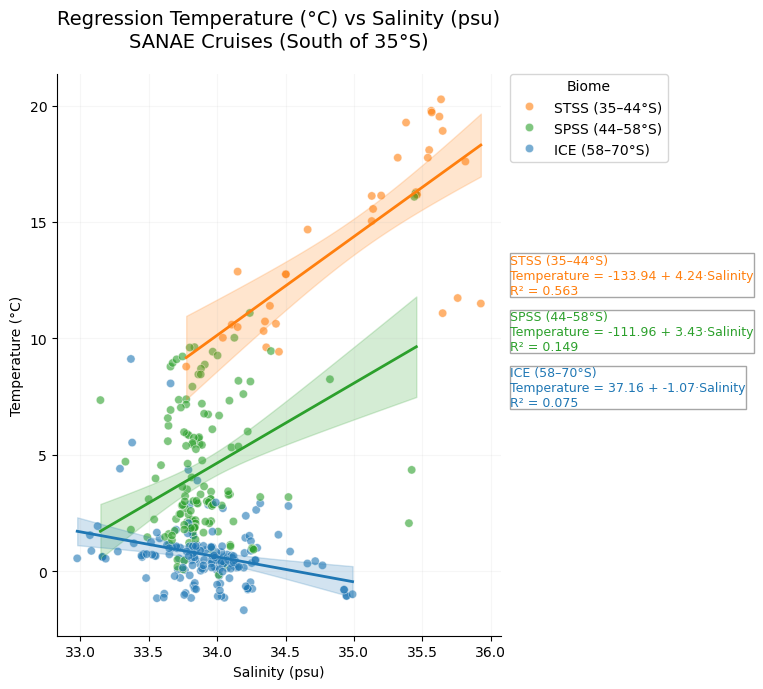


Biome-wise Mean, Std, and Sample Size for Salinity vs Temperature:
         Biome  Mean Salinity  Std Salinity  Mean Temperature  Std Temperature   n
STSS (35–44°S)          35.05          0.62             14.59             3.50  38
SPSS (44–58°S)          33.92          0.36              4.38             3.19 142
 ICE (58–70°S)          33.92          0.36              0.71             1.41 162


/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eqn = f"{biome}\n{yvar} = {coef[0]:.2f} + {coef[1]:.2f}·{xvar}\nR² = {model.rsquared:.3f}"
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eqn = f"{biome}\n{yvar} = {coef[0]:.2f} + {coef[1]:.2f}·{xvar}\nR² = {model.rsquared:.3f}"
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, inte

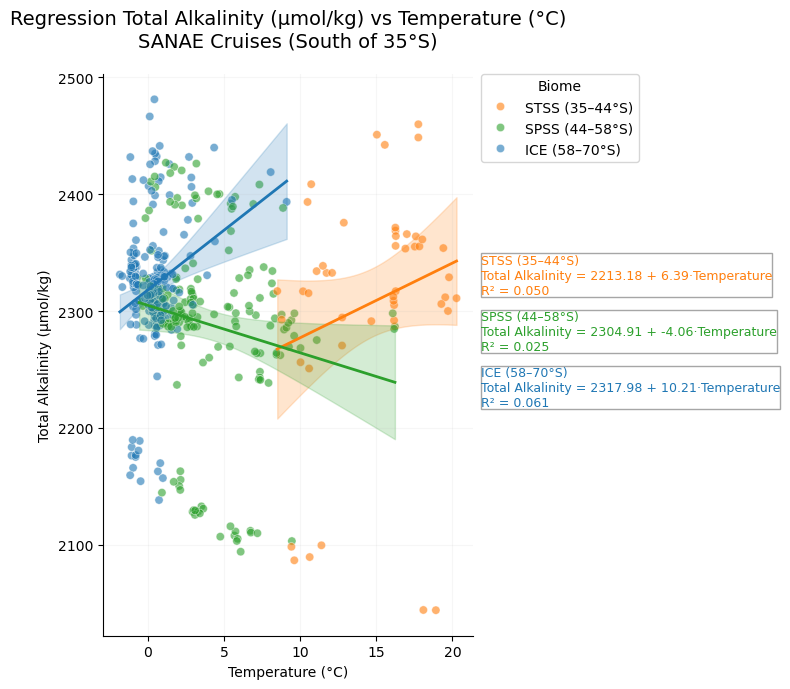


Biome-wise Mean, Std, and Sample Size for Temperature vs Total Alkalinity:
         Biome  Mean Temperature  Std Temperature  Mean Total Alkalinity  Std Total Alkalinity   n
STSS (35–44°S)             14.73             3.55                2307.37                101.01  47
SPSS (44–58°S)              4.34             3.17                2287.30                 82.02 164
 ICE (58–70°S)              0.42             1.41                2322.26                 58.45 202


/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eqn = f"{biome}\n{yvar} = {coef[0]:.2f} + {coef[1]:.2f}·{xvar}\nR² = {model.rsquared:.3f}"
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eqn = f"{biome}\n{yvar} = {coef[0]:.2f} + {coef[1]:.2f}·{xvar}\nR² = {model.rsquared:.3f}"
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, inte

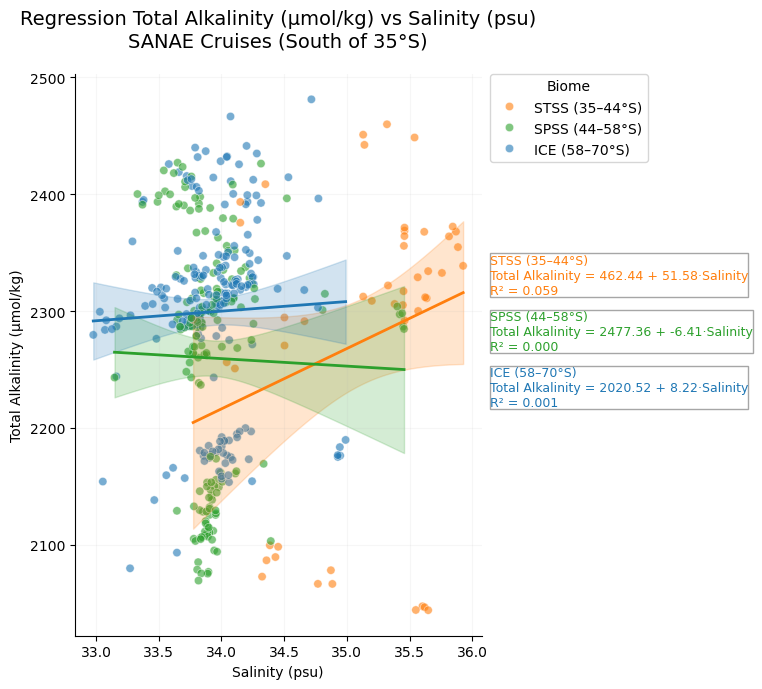


Biome-wise Mean, Std, and Sample Size for Salinity vs Total Alkalinity:
         Biome  Mean Salinity  Std Salinity  Mean Total Alkalinity  Std Total Alkalinity   n
STSS (35–44°S)          35.13          0.60                2274.64                128.39  48
SPSS (44–58°S)          33.93          0.33                2259.78                101.30 176
 ICE (58–70°S)          33.93          0.35                2299.38                 81.01 202


/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eqn = f"{biome}\n{yvar} = {coef[0]:.2f} + {coef[1]:.2f}·{xvar}\nR² = {model.rsquared:.3f}"
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eqn = f"{biome}\n{yvar} = {coef[0]:.2f} + {coef[1]:.2f}·{xvar}\nR² = {model.rsquared:.3f}"
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, inte

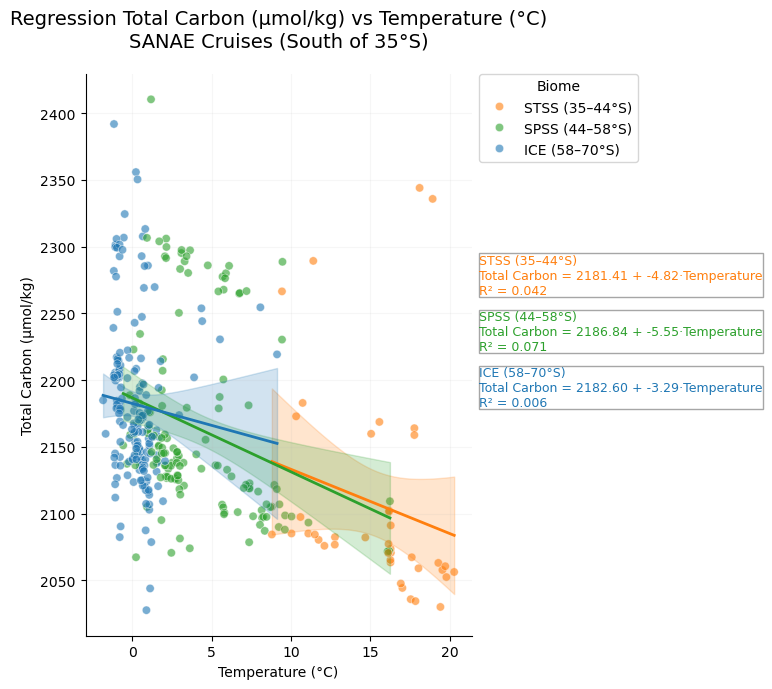


Biome-wise Mean, Std, and Sample Size for Temperature vs Total Carbon:
         Biome  Mean Temperature  Std Temperature  Mean Total Carbon  Std Total Carbon   n
STSS (35–44°S)             15.36             3.32            2107.38             78.10  41
SPSS (44–58°S)              4.35             3.34            2162.71             69.58 139
 ICE (58–70°S)              0.33             1.42            2181.51             60.18 174


/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eqn = f"{biome}\n{yvar} = {coef[0]:.2f} + {coef[1]:.2f}·{xvar}\nR² = {model.rsquared:.3f}"
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eqn = f"{biome}\n{yvar} = {coef[0]:.2f} + {coef[1]:.2f}·{xvar}\nR² = {model.rsquared:.3f}"
/var/folders/4l/xg0bv5_n0hg_ntfn6_23g55r0000gp/T/ipykernel_30065/1988656944.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, inte

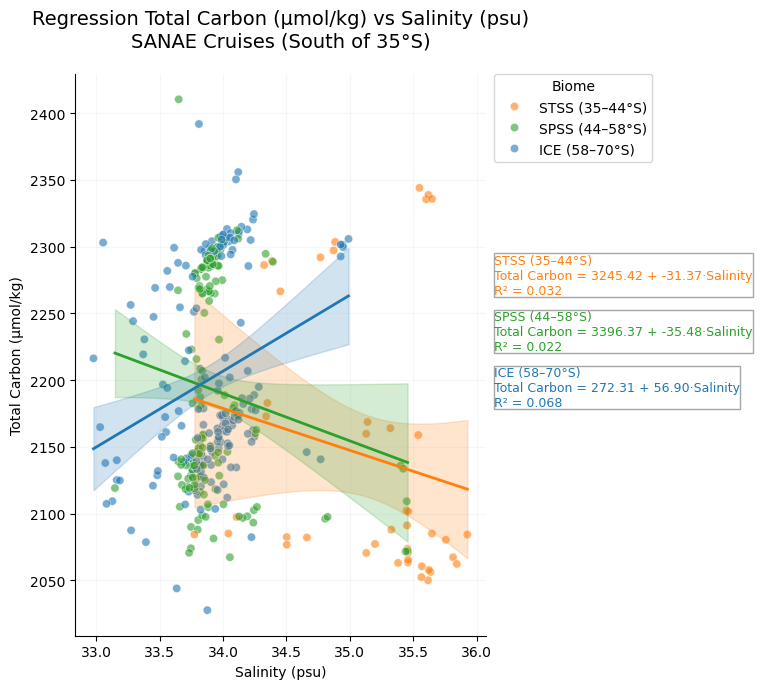


Biome-wise Mean, Std, and Sample Size for Salinity vs Total Carbon:
         Biome  Mean Salinity  Std Salinity  Mean Total Carbon  Std Total Carbon   n
STSS (35–44°S)          35.16          0.57            2142.54             99.46  43
SPSS (44–58°S)          33.94          0.34            2192.12             79.67 149
 ICE (58–70°S)          33.90          0.34            2201.02             75.30 175


In [40]:
# --- Biome assignment function ---
def assign_biome(lat):
    if -44 <= lat < -35:
        return "STSS (35–44°S)"
    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"
    elif -70 <= lat < -58:
        return "ICE (58–70°S)"
    else:
        return "Outside Defined Biome"

# --- Filter for summer only ---
df_summer = df[df['Season'].str.lower() == 'summer'].copy()
df_summer['Biome'] = df_summer['Lat'].apply(assign_biome)

# --- Exclude outside biomes ---
biome_order = ["STSS (35–44°S)", "SPSS (44–58°S)", "ICE (58–70°S)"]
df_summer = df_summer[df_summer['Biome'].isin(biome_order)]

# --- General regression plotting function ---
def biome_regression_plot(xvar, yvar, xlabel, ylabel, filename):
    fig, ax = plt.subplots(figsize=(10,7))
    sns.scatterplot(
        data=df_summer,
        x=xvar,
        y=yvar,
        hue='Biome',
        hue_order=biome_order,
        palette={'STSS (35–44°S)':'#ff7f0e',
                 'SPSS (44–58°S)':'#2ca02c',
                 'ICE (58–70°S)': '#1f77b4'},
        alpha=0.6,
        ax=ax
    )

    summary_stats = []

    for biome, color in zip(biome_order, ['#ff7f0e','#2ca02c','#1f77b4']):
        subset = df_summer[df_summer['Biome'] == biome].dropna(subset=[xvar,yvar])
        if len(subset) > 2:
            X = sm.add_constant(subset[xvar])
            y = subset[yvar]
            model = sm.OLS(y, X).fit()
            coef = model.params

            # Regression line + CI
            x_vals = np.linspace(subset[xvar].min(), subset[xvar].max(), 100)
            X_pred = sm.add_constant(x_vals)
            y_pred = model.predict(X_pred)
            ci = model.get_prediction(X_pred).conf_int()

            ax.plot(x_vals, y_pred, color=color, lw=2)
            ax.fill_between(x_vals, ci[:,0], ci[:,1], color=color, alpha=0.2)

            # Equation annotation stacked below legend
            eqn = f"{biome}\n{yvar} = {coef[0]:.2f} + {coef[1]:.2f}·{xvar}\nR² = {model.rsquared:.3f}"
            ax.text(
                1.02,
                0.68 - 0.1*biome_order.index(biome),
                eqn,
                transform=ax.transAxes,
                fontsize=9,
                color=color,
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', pad=0.2)
            )

            # Collect mean/std + sample size
            summary_stats.append([
                biome,
                subset[xvar].mean(), subset[xvar].std(),
                subset[yvar].mean(), subset[yvar].std(),
                len(subset)
            ])

    # Formatting
    ax.set_title(f"Regression {ylabel} vs {xlabel}\nSANAE Cruises (South of 35°S)", fontsize=14, pad=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Legend top right
    ax.legend(title="Biome", loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

    ax.grid(alpha=0.1)
    sns.despine()
    plt.tight_layout(rect=[0,0,0.78,1])

    # Save
    plt.savefig(f"{filename}.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{filename}.pdf", bbox_inches='tight')
    plt.show()

    # Summary statistics table
    summary_df = pd.DataFrame(
        summary_stats,
        columns=["Biome",f"Mean {xvar}",f"Std {xvar}",f"Mean {yvar}",f"Std {yvar}","n"]
    )
    print(f"\nBiome-wise Mean, Std, and Sample Size for {xvar} vs {yvar}:")
    print(summary_df.to_string(index=False, float_format="%.2f"))

    # Export to CSV
    summary_df.to_csv(f"{filename}_Summary.csv", index=False, float_format="%.2f")

# --- Generate all plots ---
biome_regression_plot("Salinity","Temperature","Salinity (psu)","Temperature (°C)","Temp_vs_Salinity_Biomewise_Regression")
biome_regression_plot("Temperature","Total Alkalinity","Temperature (°C)","Total Alkalinity (µmol/kg)","TA_vs_Temp_Biomewise_Regression")
biome_regression_plot("Salinity","Total Alkalinity","Salinity (psu)","Total Alkalinity (µmol/kg)","TA_vs_Salinity_Biomewise_Regression")
biome_regression_plot("Temperature","Total Carbon","Temperature (°C)","Total Carbon (µmol/kg)","CT_vs_Temp_Biomewise_Regression")
biome_regression_plot("Salinity","Total Carbon","Salinity (psu)","Total Carbon (µmol/kg)","CT_vs_Salinity_Biomewise_Regression")
